<a href="https://colab.research.google.com/github/zainabali12212/Smart-Medicine-OCR-Project/blob/main/Proposed-Pre-processing-Pipeline/Proposed%20Pre-processing%20Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proposed Pre-processing Pipeline: Experimental Results
**This notebook demonstrates the effectiveness of our image enhancement stages (Scaling, Denoising, and Binarization) on different medical label challenges.**




1.  This section initializes the environment by installing the Tesseract OCR engine and importing essential libraries for Image Processing.




In [1]:
# 1. Install Tesseract OCR engine to the Colab system
!apt-get install -y tesseract-ocr
!pip install pytesseract

# 2. Import necessary libraries
import cv2
import pytesseract
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image

print("Environment Ready: Libraries and OCR engine installed.")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Environment Ready: Libraries and OCR engine installed.


## Case 1: Handling Small Fonts (Scaling)
**Objective:** To test the effectiveness of 2x scaling on small medicine details (e.g., '100 Tablets' or '400mg') that are normally missed by standard OCR.

### Step 1: Image Upload

In [2]:
print("Upload image for CASE 1 (Small Font):")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
image = cv2.imread(file_name)

Upload image for CASE 1 (Small Font):


Saving unnamed1.jpg to unnamed1 (2).jpg


### Step 2: Scaling and Grayscale

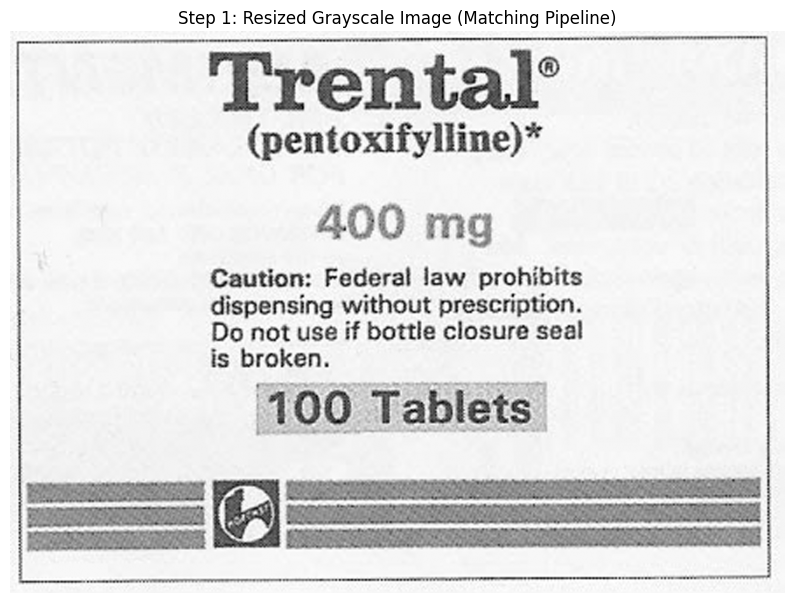

In [3]:
# Step 1: Adaptive Resizing & Grayscale Conversion
# 1. Resize first (matching Cell 4 logic)
img_resized = cv2.resize(image, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

# 2. Convert the resized image to Grayscale
gray_image = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

# Display the result
plt.figure(figsize=(10,10))
plt.imshow(gray_image, cmap='gray')
plt.title("Step 1: Resized Grayscale Image (Matching Pipeline)")
plt.axis('off')
plt.show()

### Step 3: Denoising and Binarization

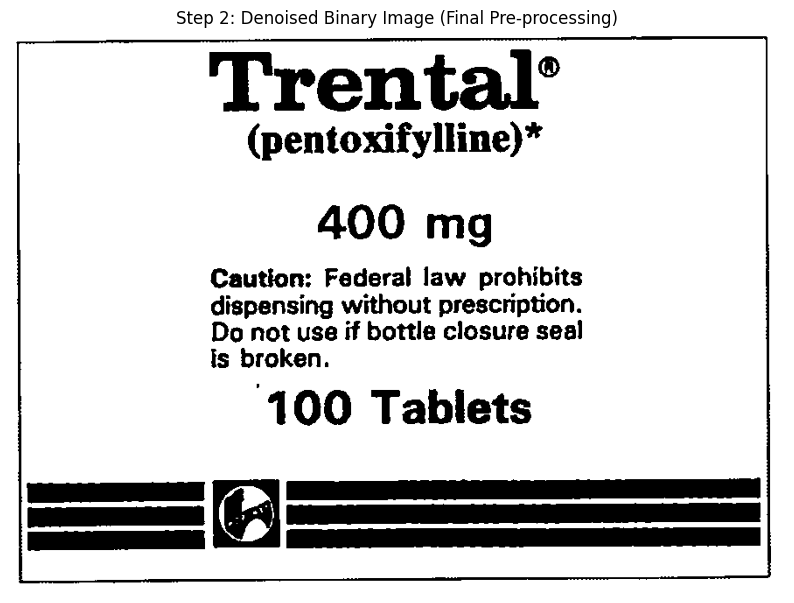

In [4]:
# Step 2: Denoising & Optimal Binarization
# 1. Denoising (Matching Cell 4 logic to remove sensor noise)
denoised_image = cv2.fastNlMeansDenoisingColored(img_resized, None, 10, 10, 7, 21)

# 2. Convert to Gray then apply Otsu's Thresholding
gray_step = cv2.cvtColor(denoised_image, cv2.COLOR_BGR2GRAY)
ret, thresh_image = cv2.threshold(gray_step, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Display the result
plt.figure(figsize=(10,10))
plt.imshow(thresh_image, cmap='gray')
plt.title("Step 2: Denoised Binary Image (Final Pre-processing)")
plt.axis('off')
plt.show()

### Step 4: Final OCR Result

In [5]:
from PIL import Image

# 1. Image Scaling (Resizing to 2x)
img_resized = cv2.resize(image, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

# 2. Denoising (Removing small dots/noise)
distorted = cv2.fastNlMeansDenoisingColored(img_resized, None, 10, 10, 7, 21)

# 3. Binarization (Converting to pure Black & White)
gray = cv2.cvtColor(distorted, cv2.COLOR_BGR2GRAY)
final_processed = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

# Convert OpenCV array to PIL Image object for Tesseract compatibility
pil_image = Image.fromarray(final_processed)

# 4. Final OCR Extraction
raw_text = pytesseract.image_to_string(pil_image).strip()

# Traffic Light Logic: Measures text quality based on noise ratio
def generate_traffic_report(text):
    clean_text = "".join(text.split())
    # Count non-alphanumeric characters as noise
    noise_count = sum(1 for char in clean_text if not char.isalnum())

    if len(clean_text) == 0:
        return "🔴 RED: OCR Failed (No text found)"
    elif noise_count > (len(clean_text) * 0.2): # 20% threshold for strict accuracy
        return "🟡 YELLOW: Low Accuracy (Text is noisy or unclear)"
    else:
        return "🟢 GREEN: Success (Clear text extracted)"

status_message = generate_traffic_report(raw_text)

# 5. Output the Result
print("="*40)
print(f"REPORT STATUS: {status_message}")
print("="*40)
print("EXTRACTED CONTENT:")
print(raw_text if raw_text else "[No Text Detected]")
print("="*40)

REPORT STATUS: 🟢 GREEN: Success (Clear text extracted)
EXTRACTED CONTENT:
Trental’

(pentoxifylline)*

400 mg

Caution: Federal law prohibits
dispensing without prescription.
Do not use if bottle closure seal
Is broken.

‘100 Tablets


## Case 2: Denoising & Otsu Binarization (Handling Noisy Backgrounds)
**Objective:** To evaluate the effectiveness of the Denoising filter and Otsu thresholding in turning textured or noisy backgrounds into pure white, isolating the text for better recognition.

### Step 1: Image Upload

In [6]:
print("Upload image for CASE 2 (Noisy Background):")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
image = cv2.imread(file_name)

Upload image for CASE 2 (Noisy Background):


Saving make-04-00043-g009.png to make-04-00043-g009 (1).png


### Step 2: Scaling and Grayscale


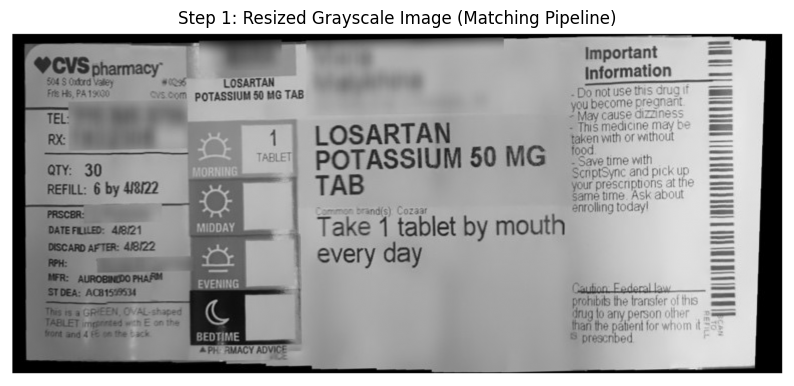

In [7]:
# Step 1: Adaptive Resizing & Grayscale Conversion
# 1. Resize first (matching Cell 4 logic)
img_resized = cv2.resize(image, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

# 2. Convert the resized image to Grayscale
gray_image = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

# Display the result
plt.figure(figsize=(10,10))
plt.imshow(gray_image, cmap='gray')
plt.title("Step 1: Resized Grayscale Image (Matching Pipeline)")
plt.axis('off')
plt.show()

### Step 3: Denoising and Binarization

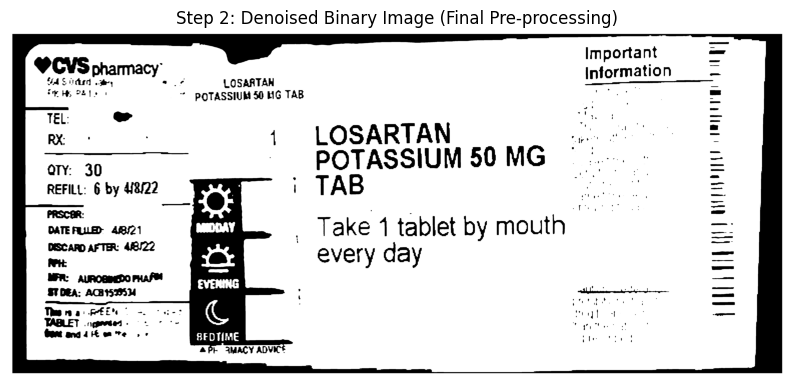

In [8]:
# Step 2: Denoising & Optimal Binarization
# 1. Denoising (Matching Cell 4 logic to remove sensor noise)
denoised_image = cv2.fastNlMeansDenoisingColored(img_resized, None, 10, 10, 7, 21)

# 2. Convert to Gray then apply Otsu's Thresholding
gray_step = cv2.cvtColor(denoised_image, cv2.COLOR_BGR2GRAY)
ret, thresh_image = cv2.threshold(gray_step, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Display the result
plt.figure(figsize=(10,10))
plt.imshow(thresh_image, cmap='gray')
plt.title("Step 2: Denoised Binary Image (Final Pre-processing)")
plt.axis('off')
plt.show()

### Step 4: Final OCR Result

In [9]:
from PIL import Image

# 1. Image Scaling (Resizing to 2x)
img_resized = cv2.resize(image, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

# 2. Denoising (Removing small dots/noise)
distorted = cv2.fastNlMeansDenoisingColored(img_resized, None, 10, 10, 7, 21)

# 3. Binarization (Converting to pure Black & White)
gray = cv2.cvtColor(distorted, cv2.COLOR_BGR2GRAY)
final_processed = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

# Convert OpenCV array to PIL Image object for Tesseract compatibility
pil_image = Image.fromarray(final_processed)

# 4. Final OCR Extraction
raw_text = pytesseract.image_to_string(pil_image).strip()

# Traffic Light Logic: Measures text quality based on noise ratio
def generate_traffic_report(text):
    clean_text = "".join(text.split())
    # Count non-alphanumeric characters as noise
    noise_count = sum(1 for char in clean_text if not char.isalnum())

    if len(clean_text) == 0:
        return "🔴 RED: OCR Failed (No text found)"
    elif noise_count > (len(clean_text) * 0.2): # 20% threshold for strict accuracy
        return "🟡 YELLOW: Low Accuracy (Text is noisy or unclear)"
    else:
        return "🟢 GREEN: Success (Clear text extracted)"

status_message = generate_traffic_report(raw_text)

# 5. Output the Result
print("="*40)
print(f"REPORT STATUS: {status_message}")
print("="*40)
print("EXTRACTED CONTENT:")
print(raw_text if raw_text else "[No Text Detected]")
print("="*40)

REPORT STATUS: 🟢 GREEN: Success (Clear text extracted)
EXTRACTED CONTENT:
YCVS pharmacy” Important .
GAS AU hey _¢ LOSARTAN Information

' a
eH Sas * POTASSIUM 50 HG TAB —_—

TEL: >

RK 1 LOSARTAN

ary: 30 POTASSIUM 50 MG
REFILL: G by 48/220 ry | TAB

Take 1 tablet by mouth |
every day

  
 
   
 
  

HUT {py ey teeny eee


## Case 3: Handling Multi-Scale Text (Scale Interference)
**Objective:** To observe the pipeline's behavior when the image contains text in significantly different sizes. This case examines how a single scaling factor (2x) affects the extraction of both large titles and smaller secondary details simultaneously.

### Step 1: Image Upload

In [10]:
print("Upload image for CASE 3 (Scale Interference):")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
image = cv2.imread(file_name)

Upload image for CASE 3 (Scale Interference):


Saving How-Read-a-Medication-Label-4.png to How-Read-a-Medication-Label-4 (1).png


### Step 2: Scaling and Grayscale


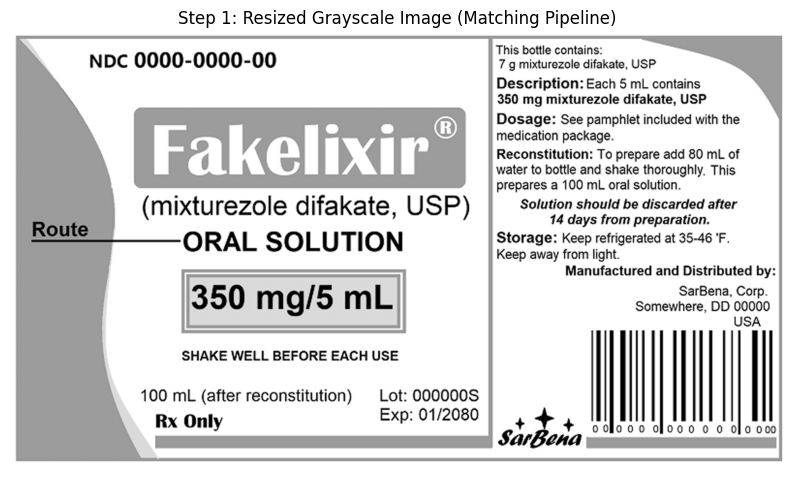

In [11]:
# Step 1: Adaptive Resizing & Grayscale Conversion
# 1. Resize first (matching Cell 4 logic)
img_resized = cv2.resize(image, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

# 2. Convert the resized image to Grayscale
gray_image = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

# Display the result
plt.figure(figsize=(10,10))
plt.imshow(gray_image, cmap='gray')
plt.title("Step 1: Resized Grayscale Image (Matching Pipeline)")
plt.axis('off')
plt.show()

### Step 3: Denoising and Binarization

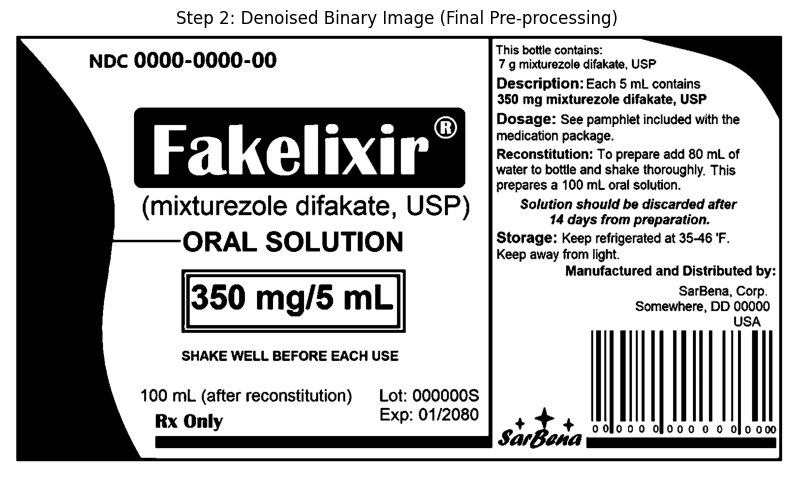

In [12]:
# Step 2: Denoising & Optimal Binarization
# 1. Denoising (Matching Cell 4 logic to remove sensor noise)
denoised_image = cv2.fastNlMeansDenoisingColored(img_resized, None, 10, 10, 7, 21)

# 2. Convert to Gray then apply Otsu's Thresholding
gray_step = cv2.cvtColor(denoised_image, cv2.COLOR_BGR2GRAY)
ret, thresh_image = cv2.threshold(gray_step, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Display the result
plt.figure(figsize=(10,10))
plt.imshow(thresh_image, cmap='gray')
plt.title("Step 2: Denoised Binary Image (Final Pre-processing)")
plt.axis('off')
plt.show()

### Step 4: Final OCR Result

In [13]:
from PIL import Image

# 1. Image Scaling (Resizing to 2x)
img_resized = cv2.resize(image, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

# 2. Denoising (Removing small dots/noise)
distorted = cv2.fastNlMeansDenoisingColored(img_resized, None, 10, 10, 7, 21)

# 3. Binarization (Converting to pure Black & White)
gray = cv2.cvtColor(distorted, cv2.COLOR_BGR2GRAY)
final_processed = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

# Convert OpenCV array to PIL Image object for Tesseract compatibility
pil_image = Image.fromarray(final_processed)

# 4. Final OCR Extraction
raw_text = pytesseract.image_to_string(pil_image).strip()

# Traffic Light Logic: Measures text quality based on noise ratio
def generate_traffic_report(text):
    clean_text = "".join(text.split())
    # Count non-alphanumeric characters as noise
    noise_count = sum(1 for char in clean_text if not char.isalnum())

    if len(clean_text) == 0:
        return "🔴 RED: OCR Failed (No text found)"
    elif noise_count > (len(clean_text) * 0.2): # 20% threshold for strict accuracy
        return "🟡 YELLOW: Low Accuracy (Text is noisy or unclear)"
    else:
        return "🟢 GREEN: Success (Clear text extracted)"

status_message = generate_traffic_report(raw_text)

# 5. Output the Result
print("="*40)
print(f"REPORT STATUS: {status_message}")
print("="*40)
print("EXTRACTED CONTENT:")
print(raw_text if raw_text else "[No Text Detected]")
print("="*40)

REPORT STATUS: 🟢 GREEN: Success (Clear text extracted)
EXTRACTED CONTENT:
This bottle contains:
NDC 0000-0000-00 7 g mixturezole difakate, USP
Description: Each 5 mL contains
350 mg mixturezole difakate, USP
Dosage: See pamphlet included with the

e e ® medication package.
a rs | «| r Reconstitution: To prepare add 80 mL of
water to bottle and shake thoroughly. This

prepares a 100 mL oral solution.

(m ixtu rezol e d ifa kate , U S P) Solution should be discarded after

14 days from preparation.

OR AL SOLUTIO N Storage: Keep refrigerated at 35-46 'F.

Keep away from light.
Manufactured and Distributed by:

350 m g/ 5 m L Somewhere DD cao

SHAKE WELL BEFORE EACH USE
100 mL (after reconstitution) | Lot: 000000S
Rx Only Exp: 01/2080 qT
NS
Sar,
